# 🧬 Pipeline scRNA-seq — IBD Colon/Recto

## Control de calidad interactivo por muestra con umbrales ajustables

**Flujo de trabajo:**
1. Cargar archivos `.h5ad`
2. Para **cada muestra**: calcular métricas → visualizar → ajustar umbrales con sliders → confirmar filtro
3. Resumen global y guardado de archivos filtrados

⚠️ Notebook exploratorio. Los valores iniciales de los sliders son los umbrales
oficiales usados en la memoria del TFM (config/qc_thresholds.yaml). Puedes
moverlos libremente para explorar — no afecta al pipeline reproducible, que
usa scripts/01_qc.py.

# · Importaciones y configuración

In [ ]:
# Montar Google Drive y prepara el gestor de entornos Conda,
# que aísla las dependencias del proyecto del entorno base de Colab.
from google.colab import drive
drive.mount('/content/drive')

!pip install -q condacolab
import condacolab
condacolab.install()

Mounted at /content/drive
⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/25.11.0-1/Miniforge3-25.11.0-1-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:13
🔁 Restarting kernel...


In [ ]:
# Instalación del entorno Conda del proyecto (environment.yml), con las
# versiones exactas de todas las dependencias fijadas para reproducibilidad.

!conda env update -n base -f /content/drive/MyDrive/TFM_IBD_GSE214695/environment.yml -q

Retrieving notices: ...working... done
Channels:
 - conda-forge
 - bioconda
 - defaults
Platform: linux-64
Solving environment: ...working... done
Preparing transaction: ...working... done
Verifying transaction: ...working... done
Executing transaction: ...working... done
Installing pip dependencies: ...working... done


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import os, gc, glob, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scanpy as sc
import anndata as ad
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from pathlib import Path
import time
import yaml
import scipy.sparse as sp
import shutil

sc.settings.verbosity = 1
matplotlib.rcParams['figure.dpi'] = 100

print("Librerías cargadas.")

# Activa la extensión de widgets en Colab
from google.colab import output
output.enable_custom_widget_manager()

Librerías cargadas.


# · Configuración de rutas

In [ ]:
REPO_ROOT = Path("/content/drive/MyDrive/TFM_IBD_GSE214695")
with open(REPO_ROOT / "config" / "params.yaml") as f:
    PARAMS = yaml.safe_load(f)
with open(REPO_ROOT / "config" / "qc_thresholds.yaml") as f:
    QC_CFG = yaml.safe_load(f)["qc"]

PROJECT_ROOT = os.environ.get(PARAMS["project_root_env_var"], PARAMS["project_root_default"])

GDRIVE_FOLDER = f"{PROJECT_ROOT}/{PARAMS['paths']['interim']['00_raw_h5ad']}/"
FILT_DIR = Path(f"{PROJECT_ROOT}/{PARAMS['paths']['interim']['01_qc_filtered']}")
FIG_DIR  = REPO_ROOT / PARAMS['paths']['reports']['figures']['01_qc']
REP_DIR  = REPO_ROOT / PARAMS['paths']['reports']['tables']['01_qc']

for d in (FILT_DIR, FIG_DIR, REP_DIR):
    d.mkdir(parents=True, exist_ok=True)

MIN_CELLS_PER_GENE = 3
RUN_SCRUBLET = QC_CFG["run_scrublet"]       # Detección de dobletes por muestra

# ── Umbral de pre-filtro por UMIs ─────────────────────────────────
# El umbral de pre-filtro por UMIs se determina muestra a muestra
# mediante la tabla de rangos. El valor inicial del slider se ajusta
# automáticamente al valle detectado. Este valor por defecto (100) solo
# se usa si la detección automática falla.
UMI_PREFILT_THRESHOLD = QC_CFG["umi_prefilt_threshold_default"]

# ── Límite mitocondrial ───────────────────────────────────────────
# Establecido en 50% tras consultar el paper original del dataset, donde los autores usaron
# hasta 65% para células epiteliales.
MITO_ABSOLUTE_MAX = QC_CFG["mito_absolute_max"]

print(f"Configuración lista.")

# Verificar que la carpeta existe y listar los archivos

h5ad_files = sorted(glob.glob(os.path.join(GDRIVE_FOLDER, "*.h5ad")))
if not h5ad_files:
    raise FileNotFoundError(
        f"No se encontraron archivos .h5ad en:\\n{GDRIVE_FOLDER}\\n")

print(f"Encontrados {len(h5ad_files)} archivos .h5ad:")
for i, f in enumerate(h5ad_files, 1):
    size_mb = os.path.getsize(f) / 1e6
    print(f"   {i:>2}. {Path(f).name:<45} ({size_mb:.1f} MB)")

Configuración lista.
Encontrados 18 archivos .h5ad:
    1. GSM6614348_HC-1.h5ad                          (77.7 MB)
    2. GSM6614349_HC-2.h5ad                          (567.7 MB)
    3. GSM6614350_HC-3.h5ad                          (568.9 MB)
    4. GSM6614351_HC-4.h5ad                          (554.2 MB)
    5. GSM6614352_HC-5.h5ad                          (566.8 MB)
    6. GSM6614353_HC-6.h5ad                          (544.9 MB)
    7. GSM6614354_UC-1.h5ad                          (523.8 MB)
    8. GSM6614355_UC-2.h5ad                          (537.1 MB)
    9. GSM6614356_UC-3.h5ad                          (535.6 MB)
   10. GSM6614357_UC-4.h5ad                          (552.0 MB)
   11. GSM6614358_UC-5.h5ad                          (556.2 MB)
   12. GSM6614359_UC-6.h5ad                          (548.5 MB)
   13. GSM6614360_CD-1.h5ad                          (557.3 MB)
   14. GSM6614361_CD-2.h5ad                          (529.5 MB)
   15. GSM6614362_CD-3.h5ad                          

# 🔧 Funciones auxiliares

In [ ]:
def get_umi_counts(adata_raw):

    # Extrae el vector de UMIs totales por barcode desde la matriz X.
    # También comprueba si hay conteos originales en adata.raw o en
    # adata.layers['counts']. Si los encuentra, los usa en lugar de X para
    # asegurar el trabajo con conteos crudos enteros.

    import scipy.sparse as sp

    if 'counts' in adata_raw.layers:
        mat = adata_raw.layers['counts']
        source = "layers['counts']"
    elif adata_raw.raw is not None:
        mat = adata_raw.raw.X
        source = "raw.X"
    else:
        mat = adata_raw.X
        source = "X"

    if sp.issparse(mat):
        umis = np.asarray(mat.sum(axis=1)).flatten()
    else:
        umis = np.asarray(mat.sum(axis=1)).flatten()

    return umis, source

def mad_outlier(values, n_mads=3.0, direction="both"):

    # Detecta outliers usando MAD (Median Absolute Deviation).
    # Que es más robusto que la desviación estándar para distribuciones asimétricas
    # como las de scRNA-seq

    # direction: 'both' | 'upper' (solo exceso) | 'lower' (solo defecto)

    m   = np.median(values)
    mad = np.median(np.abs(values - m))
    lo  = m - n_mads * mad
    hi  = m + n_mads * mad
    if direction == "both":  return (values < lo) | (values > hi)
    if direction == "upper": return values > hi
    if direction == "lower": return values < lo

def mad_threshold(values, n_mads=3.0, direction="both"):

    # Calcula los umbrales numéricos del MAD para iniciar los sliders.
    # Si el MAD o la mediana son 0, usa percentiles.

    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]  # Eliminar NaN/Inf antes de calcular

    if len(values) == 0:
        return 0.0, 1.0

    m   = float(np.median(values))
    mad = float(np.median(np.abs(values - m)))

    if mad == 0 or m == 0:
        # "lower" → P5 como límite inferior, P95 como superior
        # "upper" → P95 como límite superior
        # "both"  → P5 y P95
        lo = float(np.percentile(values, 5))
        hi = float(np.percentile(values, 95))
    else:
        lo = m - n_mads * mad
        hi = m + n_mads * mad

    lo = float(lo) if np.isfinite(lo) else 0.0
    hi = float(hi) if np.isfinite(hi) else float(np.max(values))

    return max(0.0, lo), hi

def safe_float(val, fallback=0.0):
    # Convierte val a float seguro para ipywidgets

    try:
        v = float(val)
        return v if np.isfinite(v) else fallback
    except (TypeError, ValueError):
        return fallback

def log10_ratio(adata):

    # Ratio log10(UMIs+1) / log10(genes+1) por célula.
    # Detecta muchos UMIs para pocos genes, lo cual indica un ratio bajo.

    u = adata.obs["total_counts"].values
    g = adata.obs["n_genes_by_counts"].values
    with np.errstate(divide="ignore", invalid="ignore"):
        r = np.log10(u + 1) / np.log10(g + 1)
    return np.where(np.isfinite(r), r, 0.0)

def annotate_and_compute_qc(adata):

    # Anota genes MT/ribosómicos y calcula métricas scanpy.
    # También detecta dobletes con Scrublet.

    # Genes mitocondriales (MT-) y ribosómicos (RPS*/RPL*)
    adata.var["mt"]   = adata.var_names.str.startswith("MT-")
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))

    n_mt   = adata.var["mt"].sum()
    n_ribo = adata.var["ribo"].sum()
    if n_mt == 0:
        print("Sin genes 'MT-'")

    sc.pp.calculate_qc_metrics(
        adata, qc_vars=["mt", "ribo"],
        percent_top=None, log1p=False, inplace=True
    )
    adata.obs["log10_ratio"] = log10_ratio(adata)

    # Scrublet — detección de dobletes por muestra
    if RUN_SCRUBLET:
        try:
            sc.pp.scrublet(adata, random_state=42)
        except Exception as e:
            print(f"Scrublet falló ")
            adata.obs["predicted_doublet"] = False
            adata.obs["doublet_score"]     = 0.0
    else:
        adata.obs["predicted_doublet"] = False
        adata.obs["doublet_score"]     = 0.0

    return adata, n_mt, n_ribo

def plot_qc_panel(adata, sample_name, save_path=None):

    # Panel QC completo

    obs = adata.obs
    C   = dict(main="#2E86AB", mito="#E84855", ribo="#F4A261",
               ratio="#6A4C93", doub="#2A9D8F")

    fig = plt.figure(figsize=(20, 15))
    fig.suptitle(
        f"QC Metrics — {sample_name}\n"
        f"({adata.n_obs:,} células × {adata.n_vars:,} genes)",
        fontsize=13, fontweight="bold", y=0.99
    )
    gs = gridspec.GridSpec(3, 5, figure=fig, hspace=0.48, wspace=0.4)

    # ── Violin plots ─────────────────────────────────────────────
    vmetrics = [
        ("n_genes_by_counts", "Genes / célula",      C["main"]),
        ("total_counts",      "UMIs / célula",        C["main"]),
        ("pct_counts_mt",     "% Mitocondrial",       C["mito"]),
        ("pct_counts_ribo",   "% Ribosómico",         C["ribo"]),
        ("log10_ratio",       "log₁₀(UMI)/log₁₀(g)", C["ratio"]),
    ]
    for i, (col, lbl, col_hex) in enumerate(vmetrics):
        ax = fig.add_subplot(gs[0, i])
        v  = obs[col].dropna().values
        parts = ax.violinplot(v, showmedians=True, showextrema=True, widths=0.8)
        for pc in parts["bodies"]:
            pc.set_facecolor(col_hex); pc.set_alpha(0.7)
        parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(2)
        for k in ("cmaxes","cmins","cbars"):
            parts[k].set_color("#666")
        p5, p95 = np.percentile(v, [5, 95])
        ax.axhline(p5,  color="orange", ls="--", lw=0.9, label=f"P5={p5:.0f}")
        ax.axhline(p95, color="red",    ls="--", lw=0.9, label=f"P95={p95:.0f}")
        ax.set_title(lbl, fontsize=8, fontweight="bold")
        ax.set_xticks([]); ax.tick_params(axis="y", labelsize=7)
        ax.legend(fontsize=6, loc="upper right")

    # ── Scatter UMIs vs Genes (color = doublet score) ────────────
    ax2 = fig.add_subplot(gs[1, 0:2])
    sc_ = ax2.scatter(
        obs["total_counts"], obs["n_genes_by_counts"],
        c=obs["doublet_score"].values, cmap="RdYlGn_r",
        s=0.6, alpha=0.35, rasterized=True
    )
    plt.colorbar(sc_, ax=ax2, label="Doublet score", shrink=0.8)
    ax2.set_xlabel("UMIs totales", fontsize=8)
    ax2.set_ylabel("Genes detectados", fontsize=8)
    ax2.set_title("UMIs vs Genes\n(color = doublet score)", fontsize=9, fontweight="bold")
    ax2.tick_params(labelsize=7)

    # ── Scatter UMIs vs % Mito ────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 2:4])
    ax3.scatter(obs["total_counts"], obs["pct_counts_mt"],
                c=C["mito"], s=0.6, alpha=0.35, rasterized=True)
    ax3.set_xlabel("UMIs totales", fontsize=8)
    ax3.set_ylabel("% Mitocondrial", fontsize=8)
    ax3.set_title("UMIs vs % Mitocondrial", fontsize=9, fontweight="bold")
    ax3.tick_params(labelsize=7)

    # ── Scatter % Mito vs % Ribo ──────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 4])
    ax4.scatter(obs["pct_counts_mt"], obs["pct_counts_ribo"],
                c=C["doub"], s=0.6, alpha=0.35, rasterized=True)
    ax4.set_xlabel("% Mitocondrial", fontsize=8)
    ax4.set_ylabel("% Ribosómico", fontsize=8)
    ax4.set_title("% Mito vs % Ribo", fontsize=9, fontweight="bold")
    ax4.tick_params(labelsize=7)

    # ── Histogramas ───────────────────────────────────────────────
    hcfg = [
        ("n_genes_by_counts", "Genes / célula",      C["main"],  None),
        ("total_counts",      "UMIs / célula",        C["main"],  None),
        ("pct_counts_mt",     "% Mitocondrial",       C["mito"],  (0, 60)),
        ("pct_counts_ribo",   "% Ribosómico",         C["ribo"],  None),
        ("log10_ratio",       "log₁₀ ratio",          C["ratio"], (0.5, 1.5)),
    ]
    for i, (col, lbl, col_hex, xlim) in enumerate(hcfg):
        ax = fig.add_subplot(gs[2, i])
        v  = obs[col].dropna().values
        ax.hist(v, bins=60, color=col_hex, alpha=0.8, edgecolor="none")
        for p, ls in zip([5,25,50,75,95], ["--","--","-","--","--"]):
            ax.axvline(np.percentile(v, p), color="black", ls=ls, lw=0.8, alpha=0.6)
        ax.set_xlabel(lbl, fontsize=8); ax.set_ylabel("Frecuencia", fontsize=8)
        ax.set_title(f"Distrib. {lbl}", fontsize=8, fontweight="bold")
        ax.tick_params(labelsize=7)
        if xlim: ax.set_xlim(xlim)

    # Pie de figura con estadísticas clave
    stats = (
        f"mediana: genes={obs.n_genes_by_counts.median():.0f}  "
        f"UMIs={obs.total_counts.median():.0f}  "
        f"mito={obs.pct_counts_mt.median():.1f}%  "
        f"ribo={obs.pct_counts_ribo.median():.1f}%  "
        f"dobletes={obs.predicted_doublet.sum():,} "
        f"({100*obs.predicted_doublet.mean():.1f}%)"
    )
    fig.text(0.5, 0.005, stats, ha="center", fontsize=8, style="italic", color="#444")

    if save_path:
        plt.savefig(save_path, dpi=110, bbox_inches="tight",
                    facecolor="white", edgecolor="none")
    plt.show()
    plt.close(fig)

print("Funciones auxiliares cargadas.")


Funciones auxiliares cargadas.


# · Estado del pipeline

In [ ]:
# Diccionario donde se acumulan los resultados de todas las muestras.
# Permite generar el resumen global al final sin recargar nada.
PIPELINE_STATE = {
    "completed":  [],   # nombres de muestras ya procesadas
    "stats":      [],   # estadísticas de cada muestra
    "thresholds": {},   # umbrales elegidos por el usuario para cada muestra
}

print("Estado del pipeline inicializado.")
print(f"Total muestras a procesar: {len(h5ad_files)}")


Estado del pipeline inicializado.
Total muestras a procesar: 18


# 🔬 QC interactivo por muestra

**Instrucciones:**
1. La celda procesará las muestras de una en una.
2. Para cada muestra se mostrará **una tabla de rangos de UMIs** para elegir el pre‑filtro, y después **figuras QC + sliders de umbrales**.
3. Ajusta el slider de pre‑filtro mirando la tabla (se busca el intervalo con **menos barcodes**, ese es el valle).
4. Pulsa "Aplicar pre‑filtro y calcular QC".
5. Mueve los sliders de QC → el contador de células supervivientes se actualiza en tiempo real.
6. Pulsar **"Confirmar filtro y guardar"**.
7. La muestra se filtrará, guardará y se pasará a la siguiente automáticamente.

> Los valores iniciales de los sliders QC son los umbrales MAD calculados automáticamente.

In [ ]:
# ── Índice de muestra actual ──────────────────────────────────────
_current_idx = len(PIPELINE_STATE["completed"])

if _current_idx >= len(h5ad_files):
    print("Todas las muestras han sido procesadas.")
else:
    h5ad_path   = h5ad_files[_current_idx]
    sample_name = Path(h5ad_path).stem
    print(f"\n{'='*60}")
    print(f"  Muestra {_current_idx+1}/{len(h5ad_files)}: {sample_name}")
    print(f"{'='*60}")

    # ──────────────────────────────────────────────────────────────
    # PASO A — Carga y extracción de UMIs
    # ──────────────────────────────────────────────────────────────
    print("  → Cargando archivo .h5ad ...")
    adata_raw = sc.read_h5ad(h5ad_path)
    n_barcodes_total = adata_raw.n_obs

    umis_all, umi_source = get_umi_counts(adata_raw)
    print(f"     Barcodes totales (RAW): {n_barcodes_total:,}")
    print(f"     Fuente de conteos: adata.{umi_source}")
    print(f"     Rango UMIs: [{umis_all.min():.0f} — {umis_all.max():.0f}]  "
          f"P50={np.percentile(umis_all,50):.0f}  "
          f"P99={np.percentile(umis_all,99):.0f}  "
          f"P99.9={np.percentile(umis_all,99.9):.0f}")

    # ──────────────────────────────────────────────────────────────
    # PASO B — Visualización de la distribución de UMIs
    # ──────────────────────────────────────────────────────────────

    print("\n  → Tabla de rangos de UMIs (busca el MÍNIMO = valle):")
    print(f"  {'Rango UMIs':<20} {'Barcodes':>10}")
    print(f"  {'-'*32}")

    p999 = int(np.percentile(umis_all[umis_all > 0], 99.9))
    breakpoints = sorted(set([10, 50, 100, 200, 300, 400, 450, 500,
                               550, 600, 800, 1000, 2000, max(3000, p999)]))
    counts_table = []
    for lo, hi in zip(breakpoints[:-1], breakpoints[1:]):
        n = int(((umis_all >= lo) & (umis_all < hi)).sum())
        counts_table.append((lo, hi, n))

    # Detectar mínimo global (valle real) ignorando rangos muy bajos
    MIN_UMI_IGNORE = 100                          # ignora rangos con límite inferior menor a este valor

    ns = [c[2] for c in counts_table]
    valley_hint = None
    best_n = None                                 # guardar el mejor valor
    for i in range(1, len(ns) - 1):
        lo, hi, n = counts_table[i]
        if lo >= MIN_UMI_IGNORE:                  # ignorar rangos muy bajos
            if best_n is None or n < best_n:
                best_n = n
                valley_hint = counts_table[i]

    for lo, hi, n in counts_table:
        marker = " ← valle (mínimo)" if valley_hint and lo == valley_hint[0] else ""
        print(f"  {lo:>6}–{hi:<8}: {n:>8,}{marker}")

    if valley_hint:
        suggested = int(valley_hint[1])
        print(f"\n  → Valle detectado en {valley_hint[0]:,}–{valley_hint[1]:,} UMIs")
        print(f"     Umbral sugerido: ≥ {suggested:,} UMIs "
              f"→ {int((umis_all >= suggested).sum()):,} células candidatas")
    else:
        suggested = UMI_PREFILT_THRESHOLD
        print(f"\n  → Valle no detectado automáticamente. Revisa la tabla manualmente.")
        print(f"     Usando umbral por defecto: {suggested:,} UMIs")


    _state = {
        "adata_raw":       adata_raw,   # referencia al objeto cargado
        "umis_all":        umis_all,
        "adata_qc":        None,
        "obs":             None,
        "n_cells_prefilt": 0,
        "thr_final":       UMI_PREFILT_THRESHOLD,
        "n_barcodes_total": n_barcodes_total,
        "sample_name":     sample_name,
        "umi_source":      umi_source,
    }

    # ──────────────────────────────────────────────────────────────
    # PASO C — Widgets de pre-filtro
    # ──────────────────────────────────────────────────────────────
    style_p  = {"description_width": "270px"}
    layout_p = widgets.Layout(width="640px")
    slider_max = max(int(np.percentile(umis_all, 99.9)) * 2, 2000)

    w_umi_thr = widgets.IntSlider(
        value=UMI_PREFILT_THRESHOLD, min=1, max=slider_max, step=10,
        description="Umbral UMIs pre-filtro (mín por barcode):",
        style=style_p, layout=layout_p, continuous_update=True
    )

    out_prefilt_count = widgets.Output()

    def update_prefilt_count(*args):
        if _state.get("umis_all") is None:
            return
        thr   = w_umi_thr.value
        _umis = _state["umis_all"]
        n     = int((_umis >= thr).sum())
        pct   = 100 * n / _state["n_barcodes_total"]
        # Barcodes justo por debajo del umbral (zona de decisión)
        margin = max(50, int(thr * 0.2))
        n_margin = int(((_umis >= thr - margin) & (_umis < thr)).sum())
        with out_prefilt_count:
            clear_output(wait=True)
            print(f">= {thr:,} UMIs -> {n:,} barcodes candidatos ({pct:.4f}% del RAW)")
            aviso = "muchos, considera bajar el umbral" if n_margin > 50 else "pocos, umbral limpio"
            print(f"Entre {thr-margin:,}–{thr:,} UMIs hay {n_margin:,} barcodes ({aviso})")

    w_umi_thr.observe(update_prefilt_count, names="value")

    # Área de salida donde aparecerán los sliders QC tras aplicar el pre-filtro
    qc_panel_out = widgets.Output()

    btn_apply = widgets.Button(
        description="Aplicar pre-filtro y calcular QC",
        button_style="primary",
        layout=widgets.Layout(width="320px", height="40px")
    )

    def on_apply_prefilt(b):

        # Aplica el pre-filtro de UMIs, calcula métricas QC y muestra los sliders.
        # Guardamos adata_qc y obs en _state (un diccionario) para que
        # la función on_confirm pueda leerlos cuando se pulse el botón de confirmar

        btn_apply.disabled    = True
        btn_apply.description = "Procesando..."
        btn_apply.button_style = "warning"

        thr_final = w_umi_thr.value
        _state["thr_final"] = thr_final

        with qc_panel_out:
            clear_output(wait=True)

            # ── Pre-filtro ─────────────────────────────────────────
            print(f"Aplicando pre-filtro >= {thr_final:,} UMIs ...")
            mask_prefilt = _state["umis_all"] >= thr_final
            adata_qc = _state["adata_raw"][mask_prefilt].copy()
            n_cells_prefilt = adata_qc.n_obs
            _state["n_cells_prefilt"] = n_cells_prefilt

            print(f"{n_cells_prefilt:,} células candidatas (>= {thr_final:,} UMIs)")
            if n_cells_prefilt < 100:
                print(f"Muy pocas células ({n_cells_prefilt}). Baja el umbral.")
                btn_apply.disabled    = False
                btn_apply.description = "Aplicar pre-filtro y calcular QC"
                btn_apply.button_style = "primary"
                return

            # ── Métricas QC y Scrublet ─────────────────────────────
            print("Calculando métricas QC y dobletes (Scrublet)...")
            adata_qc, n_mt, n_ribo = annotate_and_compute_qc(adata_qc)
            obs = adata_qc.obs

            # Guardar en _state para que on_confirm pueda acceder
            _state["adata_qc"] = adata_qc
            _state["obs"]      = obs

            print(f"Células  : {adata_qc.n_obs:,}  |  Genes: {adata_qc.n_vars:,}")
            print(f"Genes MT : {n_mt}  |  Genes ribo: {n_ribo}")
            print(f"Mediana genes : {obs.n_genes_by_counts.median():.0f}")
            print(f"Mediana UMIs  : {obs.total_counts.median():.0f}")
            print(f"Mediana % mito: {obs.pct_counts_mt.median():.1f}%")
            print(f"Mediana % ribo: {obs.pct_counts_ribo.median():.1f}%")
            print(f"Dobletes      : {obs.predicted_doublet.sum():,} "
                  f"({100*obs.predicted_doublet.mean():.1f}%)")

            # ── Panel QC ──────────────────────────────────────────
            print("Generando panel QC...")
            fig_path_pre = str(FIG_DIR / f"{sample_name}_QC_prefiltro.png")
            plot_qc_panel(adata_qc, sample_name, save_path=fig_path_pre)

            # ── Umbrales MAD para sliders ──────────────────────────
            g_lo, g_hi = mad_threshold(obs["n_genes_by_counts"].values, 3.0)
            u_lo, u_hi = mad_threshold(obs["total_counts"].values,       3.0)
            _,    m_hi = mad_threshold(obs["pct_counts_mt"].values,      3.0, "upper")
            r_lo, r_hi = mad_threshold(obs["pct_counts_ribo"].values,    3.0)
            ra_lo, _   = mad_threshold(obs["log10_ratio"].values,        3.0, "lower")

            g_real_max = int(obs["n_genes_by_counts"].max())
            u_real_max = int(obs["total_counts"].max())

            g_lo  = max(int(safe_float(g_lo, 200)),      0)
            g_hi  = min(int(safe_float(g_hi, g_real_max)), g_real_max)
            u_lo  = max(int(safe_float(u_lo, thr_final)), 0)
            u_hi  = min(int(safe_float(u_hi, u_real_max)), u_real_max)
            m_hi  = float(min(safe_float(m_hi, MITO_ABSOLUTE_MAX), MITO_ABSOLUTE_MAX))
            r_lo  = max(safe_float(r_lo, 5.0),   0.0)
            r_hi  = min(safe_float(r_hi, 100.0), 100.0)
            ra_lo = max(safe_float(ra_lo, 0.5),  0.0)

            if g_lo >= g_hi: g_lo = max(0, g_hi - 500)
            if u_lo >= u_hi: u_lo = max(0, u_hi - 1000)
            if r_lo >= r_hi: r_lo = max(0.0, r_hi - 5.0)

            # Sobrescribe el punto de partida de los sliders con los umbrales
            # congelados, si existen para esta muestra. Si no existen (sample_name nuevo
            # o valores aún null en el YAML), se mantiene el criterio MAD automático.
            _frozen = QC_CFG["per_sample"].get(sample_name, {})
            if _frozen.get("min_genes") is not None:
                g_lo, g_hi = _frozen["min_genes"], _frozen["max_genes"]
                u_lo, u_hi = _frozen["min_umis"], _frozen["max_umis"]
                m_hi       = _frozen["max_mito_pct"]
                r_lo, r_hi = _frozen["min_ribo_pct"], _frozen["max_ribo_pct"]
                ra_lo      = _frozen["min_log10_ratio"]

                print(f"Cargados umbrales congelados de config/qc_thresholds.yaml para {sample_name}")

            print("Umbrales MAD sugeridos (punto de partida):")
            print(f"Genes [{g_lo:,} — {g_hi:,}] | UMIs [{u_lo:,} — {u_hi:,}] | "
                  f"% Mito <= {m_hi:.1f}% | % Ribo [{r_lo:.1f}% — {r_hi:.1f}%] | "
                  f"log10 ratio >= {ra_lo:.2f}")

            # ── Sliders QC definitivos ─────────────────────────────
            style2  = {"description_width": "220px"}
            layout2 = widgets.Layout(width="640px")

            w_genes = widgets.IntRangeSlider(
                value=[g_lo, g_hi], min=0, max=g_real_max, step=25,
                description="Genes (min / max):",
                style=style2, layout=layout2, continuous_update=True)
            w_umis = widgets.IntRangeSlider(
                value=[u_lo, u_hi], min=0, max=u_real_max, step=100,
                description="UMIs (min / max):",
                style=style2, layout=layout2, continuous_update=True)
            w_mito = widgets.FloatSlider(
                value=float(m_hi), min=0.0, max=float(MITO_ABSOLUTE_MAX), step=0.5,
                description=f"% Mito máximo (<={MITO_ABSOLUTE_MAX:.0f}%):",
                style=style2, layout=layout2, continuous_update=True,
                readout_format=".1f")
            w_ribo = widgets.FloatRangeSlider(
                value=[float(r_lo), float(r_hi)], min=0.0, max=100.0, step=0.5,
                description="% Ribo (min / max):",
                style=style2, layout=layout2, continuous_update=True,
                readout_format=".1f")
            w_ratio = widgets.FloatSlider(
                value=float(ra_lo), min=0.0, max=1.5, step=0.01,
                description="log10 ratio mínimo:",
                style=style2, layout=layout2, continuous_update=True,
                readout_format=".2f")
            w_doublets = widgets.Checkbox(
                value=True, description="Eliminar dobletes (Scrublet)",
                style=style2, layout=layout2)

            out_counter = widgets.Output()

            def count_cells(*args):
                # Lee obs desde _state, el diccionario compartido definido más arriba
                _obs = _state["obs"]
                if _obs is None:
                    return
                g_min_, g_max_ = w_genes.value
                u_min_, u_max_ = w_umis.value
                m_max_  = w_mito.value
                r_min_, r_max_ = w_ribo.value
                ra_min_ = w_ratio.value
                rm_doub = w_doublets.value

                mask = (
                    (_obs["n_genes_by_counts"]  >= g_min_) &
                    (_obs["n_genes_by_counts"]  <= g_max_) &
                    (_obs["total_counts"]        >= u_min_) &
                    (_obs["total_counts"]        <= u_max_) &
                    (_obs["pct_counts_mt"]       <= m_max_) &
                    (_obs["pct_counts_ribo"]     >= r_min_) &
                    (_obs["pct_counts_ribo"]     <= r_max_) &
                    (_obs["log10_ratio"]         >= ra_min_)
                )
                if rm_doub:
                    mask = mask & (~_obs["predicted_doublet"].fillna(False).astype(bool))

                n_pass  = mask.sum()
                n_total = len(mask)
                pct     = 100 * n_pass / n_total

                fail_genes = ((_obs["n_genes_by_counts"] < g_min_) | (_obs["n_genes_by_counts"] > g_max_)).sum()
                fail_umis  = ((_obs["total_counts"] < u_min_) | (_obs["total_counts"] > u_max_)).sum()
                fail_mito  = (_obs["pct_counts_mt"] > m_max_).sum()
                fail_ribo  = ((_obs["pct_counts_ribo"] < r_min_) | (_obs["pct_counts_ribo"] > r_max_)).sum()
                fail_ratio = (_obs["log10_ratio"] < ra_min_).sum()
                fail_doub  = int(_obs["predicted_doublet"].fillna(False).astype(bool).sum()) if rm_doub else 0

                with out_counter:
                    clear_output(wait=True)
                    print(f"{n_pass:,} / {n_total:,} células pasarán el filtro ({pct:.1f}%)")
                    print(f"Eliminadas (con solapamiento): genes={fail_genes:,} | "
                          f"UMIs={fail_umis:,} | mito={fail_mito:,} | ribo={fail_ribo:,} | "
                          f"ratio={fail_ratio:,} | dobletes={fail_doub:,}")

            for w in [w_genes, w_umis, w_mito, w_ribo, w_ratio, w_doublets]:
                w.observe(count_cells, names="value")

            btn_confirm = widgets.Button(
                description="Confirmar filtro y guardar",
                button_style="success",
                layout=widgets.Layout(width="300px", height="40px"))
            btn_out2 = widgets.Output()

            def on_confirm(b):
                # Igual que antes: leemos adata_qc y obs desde _state, no
                # directamente, porque este botón es otro callback distinto
                _adata_qc = _state["adata_qc"]
                _obs      = _state["obs"]
                if _adata_qc is None:
                    with btn_out2:
                        print("Error: datos no cargados. Aplica el pre-filtro primero.")
                    return

                btn_confirm.disabled    = True
                btn_confirm.description = "Guardando..."
                btn_confirm.button_style = "warning"

                g_min_, g_max_ = w_genes.value
                u_min_, u_max_ = w_umis.value
                m_max_  = w_mito.value
                r_min_, r_max_ = w_ribo.value
                ra_min_ = w_ratio.value
                rm_doub = w_doublets.value

                mask = (
                    (_obs["n_genes_by_counts"]  >= g_min_) &
                    (_obs["n_genes_by_counts"]  <= g_max_) &
                    (_obs["total_counts"]        >= u_min_) &
                    (_obs["total_counts"]        <= u_max_) &
                    (_obs["pct_counts_mt"]       <= m_max_) &
                    (_obs["pct_counts_ribo"]     >= r_min_) &
                    (_obs["pct_counts_ribo"]     <= r_max_) &
                    (_obs["log10_ratio"]         >= ra_min_)
                )
                if rm_doub:
                    mask = mask & (~_obs["predicted_doublet"].fillna(False).astype(bool))

                adata_filt = _adata_qc[mask].copy()
                n_out    = adata_filt.n_obs
                n_rem    = _adata_qc.n_obs - n_out
                pct_rem  = 100 * n_rem / _adata_qc.n_obs

                stats_entry = {
                    "sample":           _state["sample_name"],
                    "barcodes_raw":     _state["n_barcodes_total"],
                    "umi_source":       _state["umi_source"],
                    "umi_prefilt_thr":  _state["thr_final"],
                    "cells_prefilt":    _state["n_cells_prefilt"],
                    "cells_filtered":   n_out,
                    "cells_removed_qc": n_rem,
                    "pct_removed_qc":   pct_rem,
                    "min_genes":        g_min_, "max_genes": g_max_,
                    "min_umis":         u_min_, "max_umis":  u_max_,
                    "max_mito_pct":     m_max_,
                    "min_ribo_pct":     r_min_, "max_ribo_pct": r_max_,
                    "min_log10_ratio":  ra_min_,
                    "remove_doublets":  rm_doub,
                    "genes_final":      adata_filt.n_vars,   # después de filter_genes
                }

                # Se guarda dentro del propio .h5ad como red de seguridad:
                # si se pierde PIPELINE_STATE y el CSV, esta información
                # sigue recuperable leyendo el archivo filtrado.
                adata_filt.uns["qc_stats"] = stats_entry

                out_path = str(FILT_DIR / f"{_state['sample_name']}_filtered.h5ad")
                adata_filt.write_h5ad(out_path, compression="gzip")

                fig_path_post = str(FIG_DIR / f"{_state['sample_name']}_QC_postfiltro.png")
                plot_qc_panel(adata_filt,
                              f"{_state['sample_name']} — POST filtro",
                              save_path=fig_path_post)

                PIPELINE_STATE["stats"].append(stats_entry)
                PIPELINE_STATE["completed"].append(_state["sample_name"])
                PIPELINE_STATE["thresholds"][_state["sample_name"]] = stats_entry

                # Guardado incremental: cada muestra confirmada se escribe
                # inmediatamente en el CSV, para que un corte de sesión a
                # mitad de proceso nunca pierda el trabajo ya hecho.
                _row = pd.DataFrame([stats_entry])
                _csv_path = REP_DIR / "QC_summary_all_samples.csv"
                if _csv_path.exists():
                    _prev = pd.read_csv(_csv_path)
                    _combined = pd.concat(
                        [_prev[_prev["sample"] != stats_entry["sample"]], _row],
                        ignore_index=True
                    )
                else:
                    _combined = _row
                _combined.to_csv(_csv_path, index=False, float_format="%.2f")

                del adata_filt
                _state["adata_raw"] = None
                _state["umis_all"]  = None
                _state["adata_qc"]  = None
                _state["obs"]       = None
                gc.collect()

                btn_confirm.description  = "Guardado"
                btn_confirm.button_style = "success"

                with btn_out2:
                    clear_output(wait=True)
                    print(f"{_state['sample_name']} completada")
                    print(f"Barcodes RAW          : {_state['n_barcodes_total']:,}")
                    print(f"Tras pre-filtro UMI   : {_state['n_cells_prefilt']:,} "
                          f"(umbral >= {_state['thr_final']:,} UMIs)")
                    print(f"Tras QC definitivo    : {n_out:,} ({100-pct_rem:.1f}% del pre-filtro)")
                    print(f"Guardado: {out_path}")
                    print(f"Re-ejecuta esta celda para la siguiente muestra "
                          f"({len(PIPELINE_STATE['completed'])}/{len(h5ad_files)} completadas).")

            btn_confirm.on_click(on_confirm)
            count_cells()

            display(widgets.VBox([
                widgets.HTML(f"<b>Paso 2: Umbrales QC — {sample_name}</b>"),
                widgets.HTML(
                    f"<i>{n_cells_prefilt:,} células candidatas "
                    f"(pre-filtro >= {thr_final:,} UMIs). "
                    f"Valores iniciales = MAD 3x. Ajusta libremente.</i>"
                ),
                w_genes, w_umis, w_mito, w_ribo, w_ratio, w_doublets,
                out_counter,
                btn_confirm, btn_out2,
            ]))

        btn_apply.description  = "Pre-filtro aplicado"
        btn_apply.button_style = "success"

    btn_apply.on_click(on_apply_prefilt)

    # ── Renderizar interfaz de pre-filtro ─────────────────────────
    update_prefilt_count()

    display(widgets.VBox([
        widgets.HTML(f"<b>Paso 1: Pre-filtro de barcodes vacíos — {sample_name}</b>"),
        widgets.HTML(
            "<i>Busca el VALLE en la figura de arriba. "
            "Mueve el slider hasta ese punto y pulsa el botón.</i>"
        ),
        w_umi_thr,
        out_prefilt_count,
        btn_apply,
        qc_panel_out,
    ]))

    # adata_raw y umis_all se liberan dentro de on_confirm,
    # tras guardar el archivo filtrado.
    gc.collect()



  Muestra 1/18: GSM6614348_HC-1
  → Cargando archivo .h5ad ...
     Barcodes totales (RAW): 737,280
     Fuente de conteos: adata.X
     Rango UMIs: [0 — 37908]  P50=0  P99=22  P99.9=3608

  → Tabla de rangos de UMIs (busca el MÍNIMO = valle):
  Rango UMIs             Barcodes
  --------------------------------
      10–50      :   55,662
      50–100     :      262
     100–200     :      353
     200–300     :      140
     300–400     :       83
     400–450     :       23 ← valle (mínimo)
     450–500     :       29
     500–550     :       28
     550–600     :       34
     600–800     :       92
     800–1000    :       83
    1000–2000    :      300
    2000–15208   :    1,189

  → Valle detectado en 400–450 UMIs
     Umbral sugerido: ≥ 450 UMIs → 1,943 células candidatas


# 📊 Resumen global y exportación


Resumen CSV guardado: /content/drive/MyDrive/TFM_IBD_GSE214695/reports/tables/01_qc/QC_summary_all_samples.csv


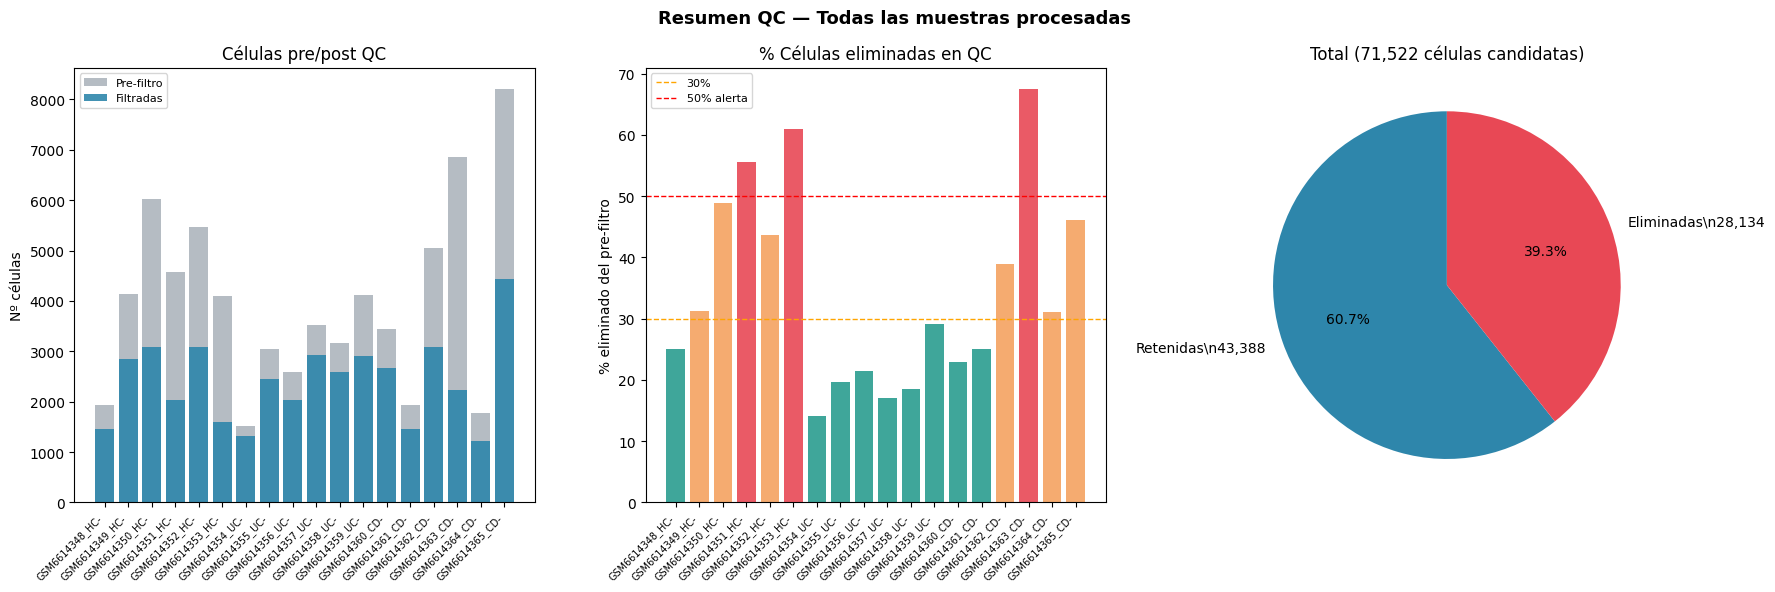

Figura resumen guardada: /content/drive/MyDrive/TFM_IBD_GSE214695/reports/tables/01_qc/QC_summary_global.png
\n=================================================================
  TABLA RESUMEN
         sample  cells_prefilt  cells_filtered  pct_removed_qc  max_mito_pct  min_genes  max_genes
GSM6614348_HC-1           1943            1455            25.1          50.0        200       2000
GSM6614349_HC-2           4139            2848            31.2          50.0        200       3360
GSM6614350_HC-3           6028            3082            48.9          50.0        200       2300
GSM6614351_HC-4           4574            2031            55.6          50.0        200       2700
GSM6614352_HC-5           5468            3082            43.6          50.0        200       2825
GSM6614353_HC-6           4104            1604            60.9          50.0        200       3000
GSM6614354_UC-1           1527            1311            14.2          50.0        200       1625
GSM6614355_UC-2

In [ ]:
if not PIPELINE_STATE["stats"]:
    print("No hay muestras procesadas aún. Ejecuta la Celda 7 primero.")
else:
    df = pd.DataFrame(PIPELINE_STATE["stats"])

    # ── CSV con todos los umbrales y estadísticas ──────────────────
    csv_path = str(REP_DIR / "QC_summary_all_samples.csv")

    # Copia de seguridad antes de sobrescribir
    if os.path.exists(csv_path):
        shutil.copy(csv_path, csv_path.replace(".csv", "_backup.csv"))

    df.to_csv(csv_path, index=False, float_format="%.2f")
    print(f"Resumen CSV guardado: {csv_path}")

    # ── Figura resumen ─────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle("Resumen QC — Todas las muestras procesadas",
                 fontsize=13, fontweight="bold")

    x    = range(len(df))
    xlbl = [s[:14] for s in df["sample"]]

    # Barras células pre/post
    axes[0].bar(x, df["cells_prefilt"],  label="Pre-filtro", color="#ADB5BD", alpha=0.9)
    axes[0].bar(x, df["cells_filtered"], label="Filtradas", color="#2E86AB", alpha=0.9)
    axes[0].set_xticks(x); axes[0].set_xticklabels(xlbl, rotation=45, ha="right", fontsize=7)
    axes[0].set_ylabel("Nº células"); axes[0].set_title("Células pre/post QC")
    axes[0].legend(fontsize=8)

    # % eliminado en la fase de QC sobre células candidatas

    pct = df["pct_removed_qc"].astype(float)
    colors = ["#E84855" if p>50 else "#F4A261" if p>30 else "#2A9D8F" for p in pct]
    axes[1].bar(x, pct, color=colors, alpha=0.9)
    axes[1].axhline(30, color="orange", ls="--", lw=1, label="30%")
    axes[1].axhline(50, color="red",    ls="--", lw=1, label="50% alerta")
    axes[1].set_xticks(x); axes[1].set_xticklabels(xlbl, rotation=45, ha="right", fontsize=7)
    axes[1].set_ylabel("% eliminado del pre-filtro")
    axes[1].set_title("% Células eliminadas en QC")
    axes[1].legend(fontsize=8)

    # Pie global
    total_r = df["cells_prefilt"].sum()
    total_f = df["cells_filtered"].sum()
    axes[2].pie(
        [total_f, total_r-total_f],
        labels=[f"Retenidas\\n{total_f:,}", f"Eliminadas\\n{total_r-total_f:,}"],
        colors=["#2E86AB","#E84855"], autopct="%1.1f%%", startangle=90
    )
    axes[2].set_title(f"Total ({total_r:,} células candidatas)")

    plt.tight_layout()
    fig_path = str(REP_DIR / "QC_summary_global.png")
    plt.savefig(fig_path, dpi=120, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    print(f"Figura resumen guardada: {fig_path}")

    # ── Tabla resumen en pantalla ──────────────────────────────────
    print("\\n" + "="*65)
    print("  TABLA RESUMEN")
    print("="*65)
    print(df[["sample","cells_prefilt","cells_filtered","pct_removed_qc",
              "max_mito_pct","min_genes","max_genes"]].to_string(
        index=False, float_format="%.1f"
    ))
    print(f"  Total pre-filtro: {total_r:,}")
    print(f"  Total filtradas : {total_f:,}  ({100*total_f/total_r:.1f}% retenido)")
    print(f"  Muestras completadas: {len(df)}/{len(h5ad_files)}")


# · Reanudar sesión tras reconexión de Colab

Si Colab se desconecta y se pierde el PIPELINE_STATE, se usa esta celda para reconstruirlo a partir de los archivos ya guardados.

In [ ]:
already_done = sorted(glob.glob(str(FILT_DIR / "*_filtered.h5ad")))
_csv_path = REP_DIR / "QC_summary_all_samples.csv"

if not already_done:
    print("No se encontraron archivos filtrados en:", FILT_DIR)
elif _csv_path.exists():
    _df_prev = pd.read_csv(_csv_path)
    PIPELINE_STATE["stats"] = _df_prev.to_dict("records")
    PIPELINE_STATE["completed"] = _df_prev["sample"].tolist()
    print(f"Sesión reconstruida desde CSV: {len(PIPELINE_STATE['completed'])} muestras.")
else:
    # Sin CSV disponible: se intenta recuperar desde los .h5ad guardados
    PIPELINE_STATE["completed"] = []
    PIPELINE_STATE["stats"]     = []
    for fpath in already_done:
        name = Path(fpath).stem.replace("_filtered", "")
        PIPELINE_STATE["completed"].append(name)
        tmp = sc.read_h5ad(fpath, backed="r")
        if "qc_stats" in tmp.uns:
            PIPELINE_STATE["stats"].append(dict(tmp.uns["qc_stats"]))
        else:
            print(f"{name}: sin qc_stats guardado, estadísticas incompletas.")
            PIPELINE_STATE["stats"].append({
                "sample": name, "cells_filtered": tmp.n_obs,
            })
        del tmp; gc.collect()
    print(f"Sesión reconstruida desde .h5ad: {len(PIPELINE_STATE['completed'])} muestras.")

if already_done:
    remaining = [f for f in h5ad_files
                 if Path(f).stem not in PIPELINE_STATE["completed"]]
    print(f"   Muestras pendientes: {len(remaining)}")
    for f in remaining:
        print(f"     - {Path(f).name}")


Sesión reconstruida desde CSV: 18 muestras.
   Muestras pendientes: 0
